# Tweedie Power Parameter Estimation

The Tweedie family `Tw_p(mu, phi)` has variance function `V(mu) = mu^p`,
where `p` controls the distribution shape:

| p | Distribution |
|---|---|
| 1 | Poisson |
| 1 < p < 2 | Compound Poisson-Gamma (mass at zero + continuous) |
| 2 | Gamma |

For insurance severity modelling, `p` typically falls in (1.1, 1.9) — a mix of
exact zeros (no claim) and positive claim amounts.

Estimating `p` from data is a **profile likelihood** problem. For each
candidate `p`, `estimate_p()`:

1. Fits the full GLM via PIRLS (warm-started from the previous `p`)
2. Estimates `phi` — either via weighted Pearson moments or nested MLE
3. Evaluates the **exact** Tweedie log-likelihood using the Wright-Bessel
   function (not a saddlepoint approximation)
4. Brent's method drives the outer loop, finding the `p` that minimises
   the negative log-likelihood

The zero mass `P(Y=0) = exp(-mu^(2-p) / ((2-p)*phi))` is what identifies
`p` — without zeros, `p` and `phi` are weakly separated.

This notebook demonstrates the full pipeline on synthetic data with
known `p` and `phi`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from superglm import Spline, SuperGLM, Tweedie
from superglm.tweedie_profile import generate_tweedie_cpg

## 1. Simulate Tweedie data

We generate data from a Compound Poisson-Gamma distribution with known
parameters. The true effect is a smooth curve in `x` with varying exposure.

Here exposure plays two roles consistently:
- it scales the mean through `mu_total = mu_rate * exposure`
- it scales the effective dispersion through `phi_eff = phi / exposure`

That means the fitted model must include `offset=np.log(exposure)` so the
mean specification matches the DGP, while `sample_weight=exposure` carries the
prior-weight dispersion convention.

Key parameters:
- **p = 1.6** — between Poisson (1) and Gamma (2)
- **phi = 2.0** — baseline dispersion (scaled by `1/exposure` per obs)


In [2]:
rng = np.random.default_rng(42)
n = 50_000
TRUE_P = 1.6
TRUE_PHI = 2.0

# Covariates
x = rng.uniform(0, 1, n)
exposure = rng.uniform(0.5, 2.0, n)

# True mean: rate per unit exposure × exposure
mu_rate = np.exp(np.log(5.0) + 0.5 * np.sin(2 * np.pi * x))
mu_total = mu_rate * exposure

# Generate Tweedie responses with matching prior-weight convention.
# The fitted model will use offset=log(exposure) and sample_weight=exposure.
y = generate_tweedie_cpg(n, mu=mu_total, phi=TRUE_PHI / exposure, p=TRUE_P, rng=rng)

X = pd.DataFrame({"x": x})

offset = np.log(exposure)
zero_rate = np.mean(y == 0)
print(f"n = {n:,}")
print(f"True p = {TRUE_P}, True phi = {TRUE_PHI}")
print(f"Zero rate: {zero_rate:.1%}")
print(f"y range: [{y.min():.1f}, {y.max():.1f}]")
print(f"y mean: {y.mean():.1f}, y[y>0] mean: {y[y > 0].mean():.1f}")

n = 50,000
True p = 1.6, True phi = 2.0
Zero rate: 9.2%
y range: [0.0, 73.4]
y mean: 6.6, y[y>0] mean: 7.3


## 2. Estimate p

We start with a deliberately wrong initial guess (`p=1.2`) and let
`estimate_p()` profile over the likelihood. Under the hood, each
Brent evaluation:

1. Fits a full PIRLS at the candidate `p` (warm-started — first fit
   is expensive, subsequent ones are cheap)
2. Estimates `phi` via weighted Pearson moments or nested MLE
3. Evaluates the exact Tweedie log-likelihood at `(mu, phi, p)` using
   `scipy.special.wright_bessel` for the density of `y > 0`, and the
   closed-form `P(Y=0)` for the point mass

Because exposure scales the true mean, the fit includes
`offset=np.log(exposure)` in addition to `sample_weight=exposure`.
With that mean specification in place, both Pearson and nested-MLE
phi profiling land close to the true `p`; the example below uses the
default Pearson profile for speed.


In [3]:
model = SuperGLM(
    family=Tweedie(p=1.2),  # deliberately wrong initial guess
    features={"x": Spline(n_knots=10)},
)

result = model.estimate_p(X, y, sample_weight=exposure, offset=offset)

print(f"Estimated p:   {result.p_hat:.4f}  (true: {TRUE_P})")
print(f"Estimated phi: {result.phi_hat:.4f}  (true: {TRUE_PHI})")
print(f"Converged:     {result.converged}")
print(f"Evaluations:   {result.n_evaluations}")

Estimated p:   1.6018  (true: 1.6)
Estimated phi: 2.0080  (true: 2.0)
Converged:     True
Evaluations:   7


## 3. Profile likelihood plot

The profile plot shows the negative log-likelihood as a function of `p`.
Each point on this curve required a full GLM fit + phi estimation +
exact likelihood evaluation. The orange dots show where Brent actually
evaluated (typically 8–12 points); the smooth curve is filled in
afterwards on a fine grid. The chi-squared cutoff for the 95% CI is
shown as a horizontal line.

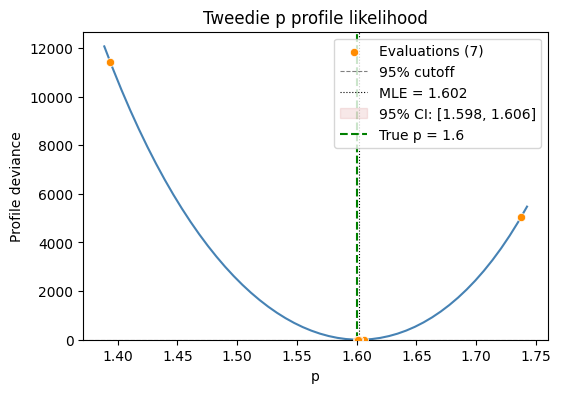

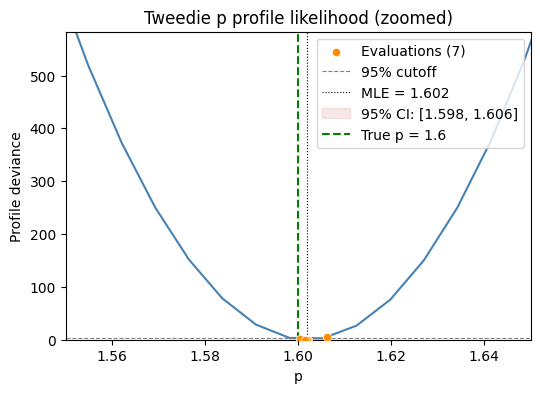

In [4]:
fig = result.profile_plot(alpha=0.05)

# Add true p as a green vertical line
ax = fig.get_axes()[0]
ax.axvline(TRUE_P, color="green", linestyle="--", linewidth=1.5, label=f"True p = {TRUE_P}")
ax.legend()
plt.show()

fig_zoom = result.profile_plot(alpha=0.05)
ax_zoom = fig_zoom.get_axes()[0]
ax_zoom.axvline(TRUE_P, color="green", linestyle="--", linewidth=1.5, label=f"True p = {TRUE_P}")

zoom_xmin, zoom_xmax = 1.55, 1.65
ax_zoom.set_xlim(zoom_xmin, zoom_xmax)

zoom_ymax = None
for line in ax_zoom.get_lines():
    x = np.asarray(line.get_xdata(), dtype=float)
    y = np.asarray(line.get_ydata(), dtype=float)
    if x.shape != y.shape or x.size == 0:
        continue
    mask = np.isfinite(x) & np.isfinite(y) & (x >= zoom_xmin) & (x <= zoom_xmax)
    if np.any(mask):
        line_ymax = float(np.max(y[mask]))
        zoom_ymax = line_ymax if zoom_ymax is None else max(zoom_ymax, line_ymax)

if zoom_ymax is not None:
    ax_zoom.set_ylim(0, zoom_ymax * 1.1 if zoom_ymax > 0 else 1.0)

ax_zoom.set_title("Tweedie p profile likelihood (zoomed)")
ax_zoom.legend()
plt.show()

## 4. Confidence interval

The profile CI inverts the likelihood ratio test: find the values of `p`
where the profile deviance equals the chi-squared cutoff. Each endpoint
requires a Brent search + GLM refit.

In [5]:
ci_lo, ci_hi = result.ci(alpha=0.05)

print(f"95% Profile CI: [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"True p = {TRUE_P} {'inside' if ci_lo <= TRUE_P <= ci_hi else 'OUTSIDE'} CI")
print(f"CI width: {ci_hi - ci_lo:.4f}")

95% Profile CI: [1.5980, 1.6061]
True p = 1.6 inside CI
CI width: 0.0081


## 5. Model summary

After `estimate_p()`, the model is refitted at the estimated `p`.
The summary includes the estimated `p` with its profile CI.

In [6]:
model.summary()

╔══════════════════════════════════════════════════════ SuperGLM Results ══════════════════════════════════════════════════════╗
║ Family:                                               Tweedie  No. Observations:                                       50000 ║
║ Link:                                                     Log  Df (effective):                          13.95 (12.95 smooth) ║
║ Method:                                                    ML  Penalty:                                          Group Lasso ║
║ Scale (phi):                                            2.008  Pearson chi2:                                        100387.4 ║
║ Log-Likelihood:                                     -141472.1  AIC:                                                 282972.0 ║
║ AICc:                                                282972.1  BIC:                                                 283095.1 ║
║ EBIC:                                                283095.1  Converged:                                      True (4 iter) ║
║ Deviance:                                            119670.2                                                                ║
║ Tweedie p:                               1.602 [1.598, 1.606]  Method:             Profile (brent, phi=pearson)  NLL: 2.8294 ║
╠══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╣
║                 coef   std err     z     P>|z|   [0.025   0.975]                                                             ║
╟──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╢
║ Intercept     1.6094    0.0039   413.8   0.000    1.602    1.617 ***                                                         ║
║                                                                                                                              ║
╠════════════════════════════════════════════════════════════╡ x ╞═════════════════════════════════════════════════════════════╣
║                                                                                                                              ║
║ x           [spline, 13 params, chi2(13.0)=8156.3, p=<0.001]                                                             *** ║
║               rank=13, edf=12.9, lam=0.1, curve SE: 0.01-0.04                                                                ║
╚══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╝
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Note: smooth p-values use Wood (2013) Bayesian test.
Parametric p-values are Wald approximations.
For borderline significance, use a likelihood ratio test.

## 6. Effect of sample size on recovery

Profile likelihood gets sharper with more data. Let's compare `p`
recovery and CI width across sample sizes.

In [7]:
sample_sizes = [5_000, 10_000, 20_000, 50_000]
results_table = []

for n_sub in sample_sizes:
    rng_sub = np.random.default_rng(123)
    x_sub = rng_sub.uniform(0, 1, n_sub)
    exp_sub = rng_sub.uniform(0.5, 2.0, n_sub)
    mu_rate_sub = np.exp(np.log(5.0) + 0.5 * np.sin(2 * np.pi * x_sub))
    mu_sub = mu_rate_sub * exp_sub
    y_sub = generate_tweedie_cpg(n_sub, mu=mu_sub, phi=TRUE_PHI / exp_sub, p=TRUE_P, rng=rng_sub)
    X_sub = pd.DataFrame({"x": x_sub})

    m = SuperGLM(family=Tweedie(p=1.5), features={"x": Spline(n_knots=8)})
    r = m.estimate_p(X_sub, y_sub, sample_weight=exp_sub, offset=np.log(exp_sub))
    ci = r.ci(alpha=0.05)
    results_table.append(
        {
            "n": n_sub,
            "p_hat": r.p_hat,
            "phi_hat": r.phi_hat,
            "ci_lo": ci[0],
            "ci_hi": ci[1],
            "ci_width": ci[1] - ci[0],
            "evals": r.n_evaluations,
        }
    )

df_results = pd.DataFrame(results_table)
df_results["error"] = df_results["p_hat"] - TRUE_P
df_results[["n", "p_hat", "error", "ci_lo", "ci_hi", "ci_width", "phi_hat", "evals"]]

,n,p_hat,error,ci_lo,ci_hi,ci_width,phi_hat,evals
0,5000,1.598114,-0.001886,1.585135,1.610887,0.025752,2.015470,7
1,10000,1.601281,0.001281,1.592254,1.610853,0.018599,1.953735,7
2,20000,1.600450,0.000450,1.594219,1.606784,0.012565,2.008680,7
3,50000,1.600116,0.000116,1.596341,1.604342,0.008001,1.990361,7


## 7. Key takeaways

- Each Brent evaluation fits a full PIRLS + estimates phi + evaluates
  the exact Tweedie log-likelihood (Wright-Bessel, not saddlepoint)
- Warm-started PIRLS makes evaluations after the first very cheap
- Profile CI inverts the likelihood ratio test via root-finding
- CI narrows with more data — compare the `ci_width` column above
- Recovery is unbiased when the simulation DGP matches the model
  assumptions (`phi_eff = phi / exposure` under frequency weights)
- `phi` is estimated via weighted Pearson moments by default; nested
  MLE is available via `phi_method="mle"` for tighter estimates